In [1]:
# reload module automatically when edited
%load_ext autoreload
%autoreload 2
from IAR_PROJET import *
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import cv2
from IPython.display import Video

Objectif : Au minimum, reproduire le modèle avec TD-learning seul, et celui avec l’ajout de la
navigation métrique. L’objectif est de produire vos propres versions des figures 3 (vérification du
bon fonctionnement du TD-RL), 4a (comportement du TD-RL dans la tâche de piscine avec un
changement de position de la plateforme), 6 (vérification du bon fonctionnement de la navigation
métrique) et 8a (comportement du système complet dans la tâche de piscine avec un
changement de place de la plateforme)

---
# Environment Class
---

### Initialize and display Environment

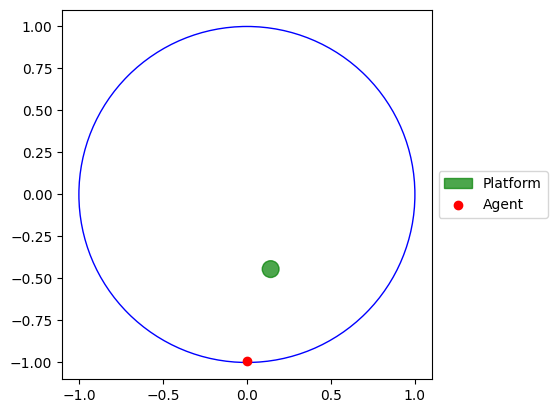

In [137]:
env = Environment()
env.display()

### Reset environment with RMW (platform stays in place)

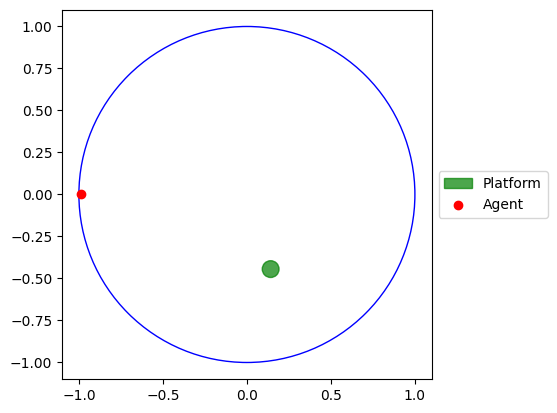

In [138]:
env.reset("RMW")
env.display()

### Reset Environment with DMP (platform is moved randomly)

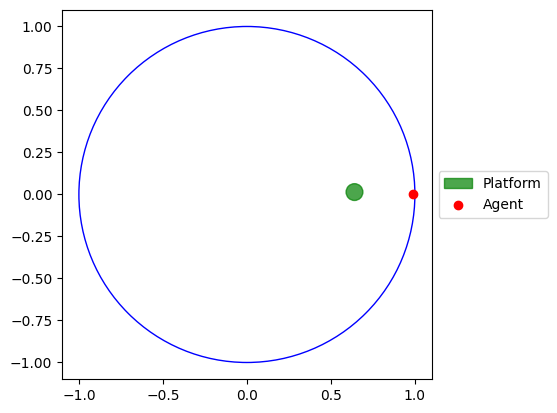

In [139]:
env.reset("DMP")
env.display()

### Step Function

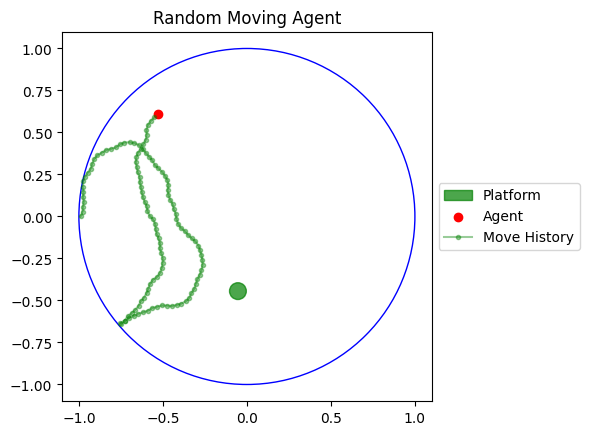

In [141]:
demoenv = DemoEnv()

max_steps = 120
fps = 20
start_pos = None
move_dir = None

demoenv.step_function_demo(max_steps=max_steps, fps=fps,
                                    start_pos=start_pos, move_dir=move_dir,
                                    save_path="animation_random.mp4",
                                    title="Random Moving Agent")
Video("animation_random.mp4", embed=True)

---
# Place Cells
---

(493, 2)


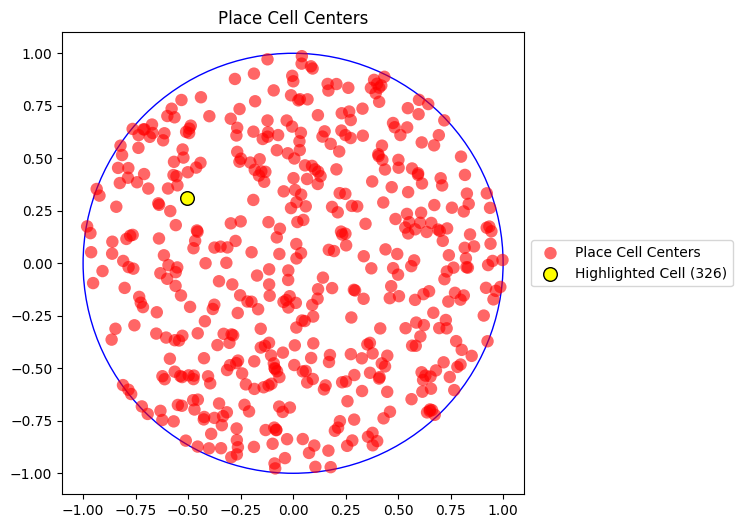

In [142]:
env = Environment()
place_cells = PlaceCells(env, n_cells=493, sigma=0.16)
print(place_cells.centers.shape)
selected_place_cell_id = np.random.randint(0, place_cells.n_cells)
place_cells.display_centers(highlight_id=selected_place_cell_id)

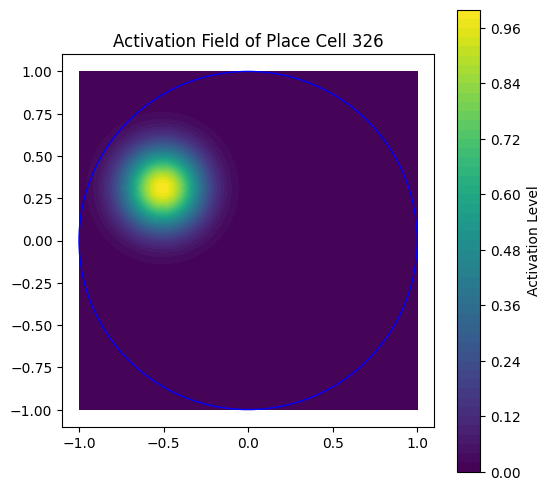

In [143]:
place_cells.display_activation_field(selected_place_cell_id, grid_size=100)

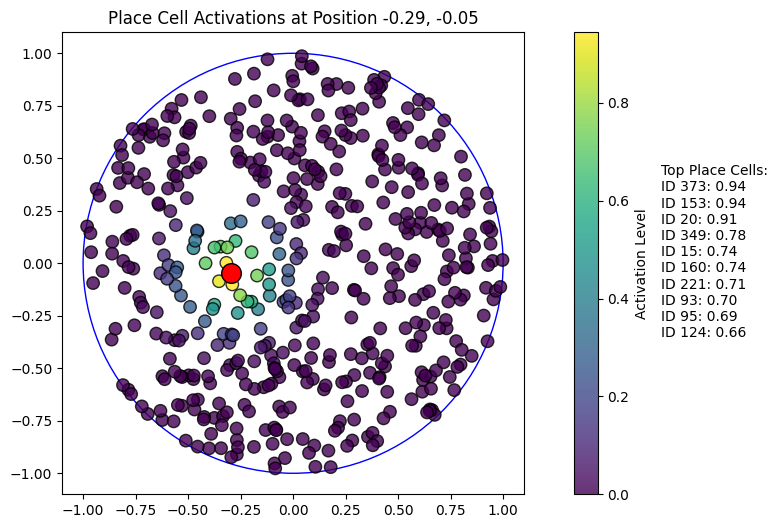

In [145]:
place_cells.display_all_place_activation_by_location()

---
# TD Agent Class
---

Trial 1: 


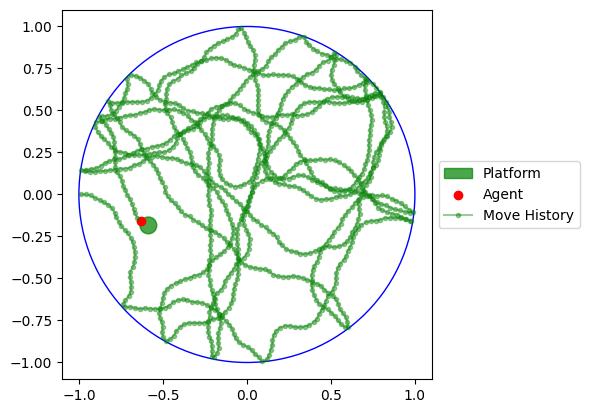

Trial 22: 


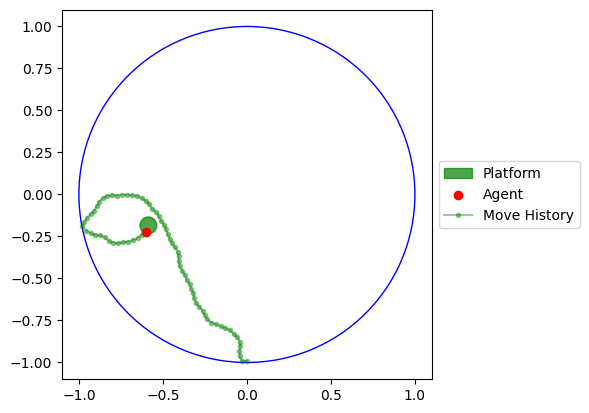

In [149]:
trial_count = 22
env = Environment()
agent = TD_Agent(env)
print(f"Trial 1: ")
#agent.critic.display_value_function()
_ = agent.run_trial("RMW")
env.display()
for _ in range(trial_count - 2):
    _ = agent.run_trial("RMW")
print(f"Trial {trial_count}: ")
#agent.critic.display_value_function()
_ = agent.run_trial("RMW")
env.display()

---
# Figure 3
---

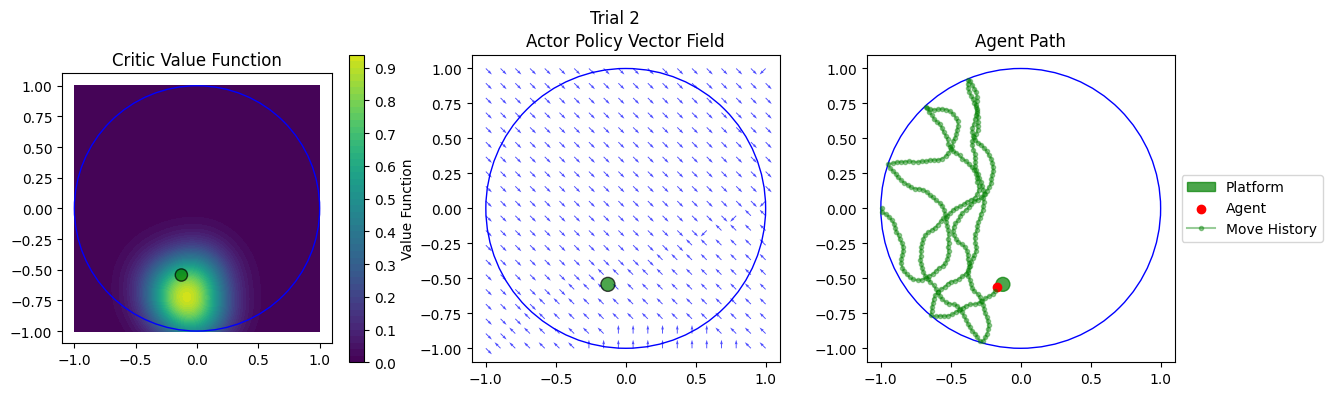

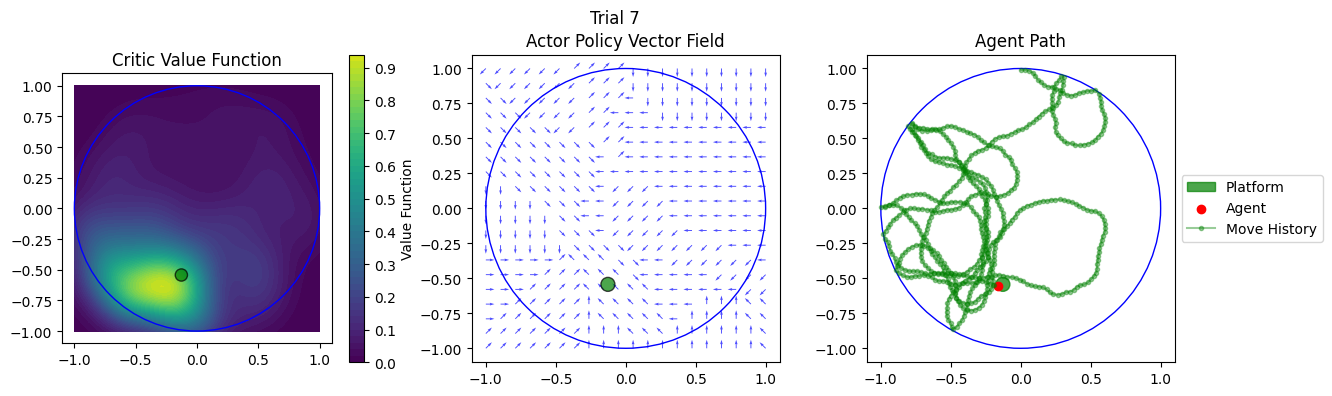

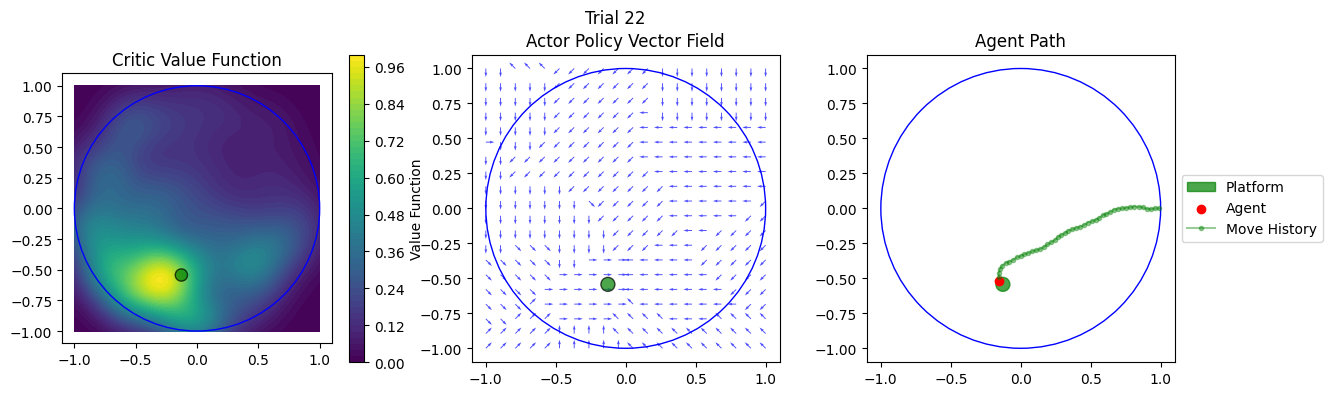

In [19]:
env = Environment()
agent = TD_Agent(env)
trial_mode = "RMW"
selected_trials = [2, 7, 22]

for trial_num in range(1, max(selected_trials) + 1):
    if trial_num in selected_trials:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        fig.suptitle(f"Trial {trial_num}")
        fig.tight_layout()
        plt.sca(axes[0])
        agent.critic.display_value_function(plt_show=False)
        plt.sca(axes[1])
        agent.actor.display_policy(plt_show=False)
        agent.run_trial(trial_mode)
        plt.sca(axes[2])
        env.display(plt_show=False, title="Agent Path")
        plt.show()
    else:
        temp = agent.run_trial(trial_mode)

---
# Figure 4
---

## Figure 4.a

Experiment Time: 65.87 seconds


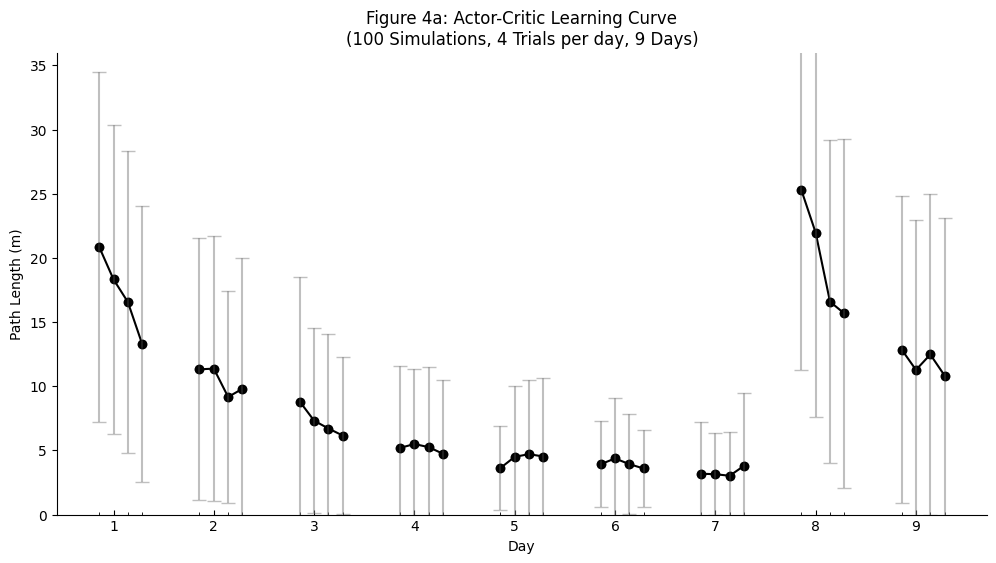

In [175]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 100

start_time = time.time()
results_4a = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure4(results_4a)

## Figure 4.b

Experiment Time: 134.53 seconds


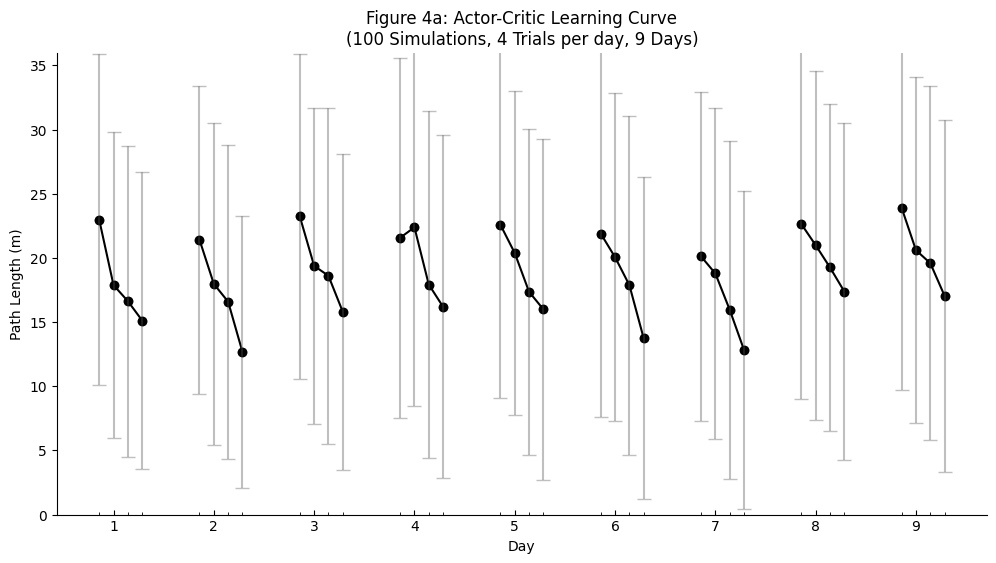

In [ ]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["DMP"] * 9
trials_per_day = 4
simulation_count = 100

start_time = time.time()
results_4b = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure4(results_4b)

---
## 1000 Simulations (Like in the paper)
---

## Figure 4.a

Experiment Time: 753.90 seconds


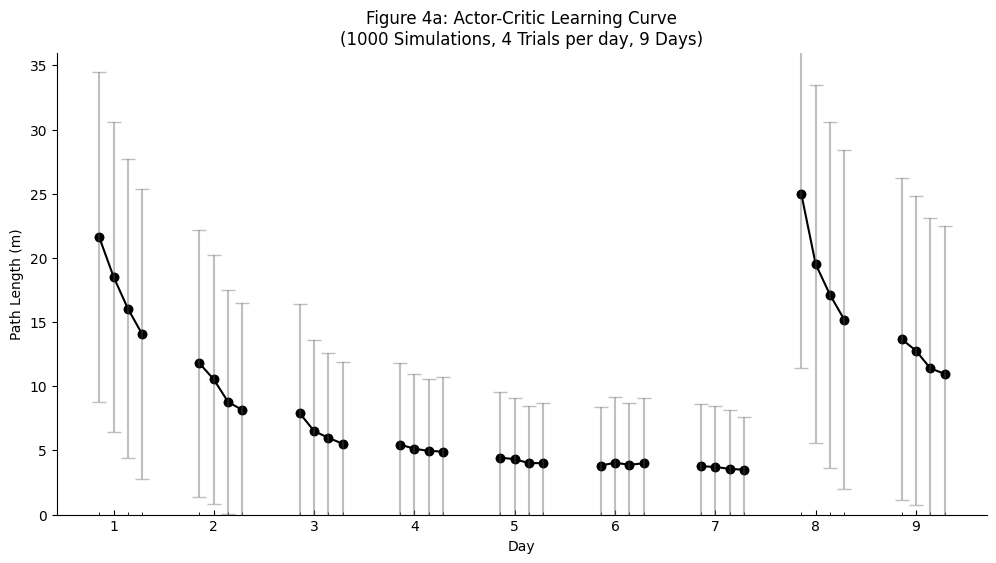

In [ ]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 1000

start_time = time.time()
results_4a = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure4(results_4a, title="Figure 4a: RMW + DMP Task\n(1000 Simulations, 4 Trials per day, 9 Days)")

## Figure 4.b

Experiment Time: 1548.84 seconds


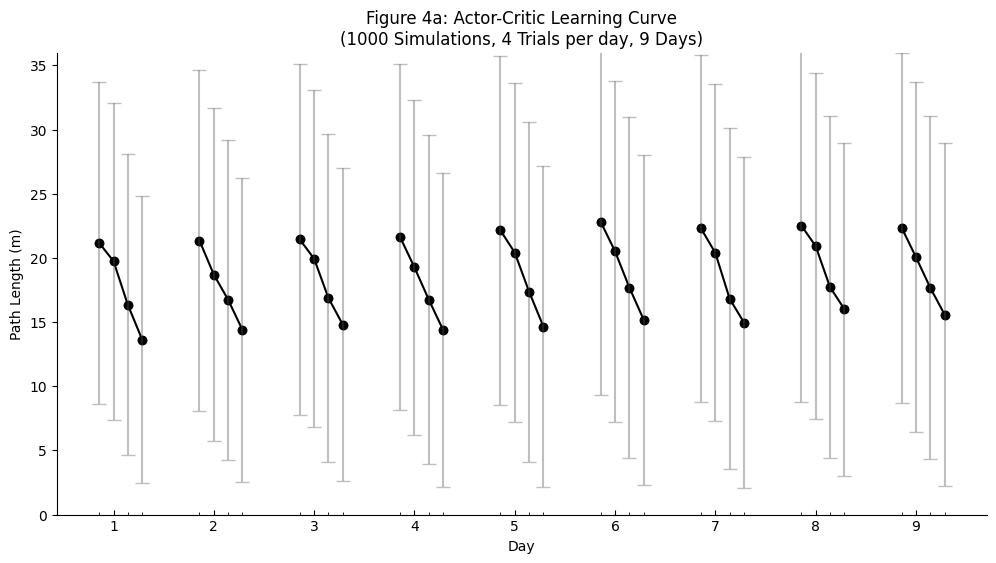

In [ ]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["DMP"] * 9
trials_per_day = 4
simulation_count = 1000

start_time = time.time()
results_4b = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure4(results_4b, title="Figure 4b: DMP Task\n(1000 Simulations, 4 Trials per day, 9 Days)")

---
# Coordinate System
---

Step 1000/10000
Step 2000/10000
Step 3000/10000
Step 4000/10000
Step 5000/10000
Step 6000/10000
Step 7000/10000
Step 8000/10000
Step 9000/10000
Step 10000/10000


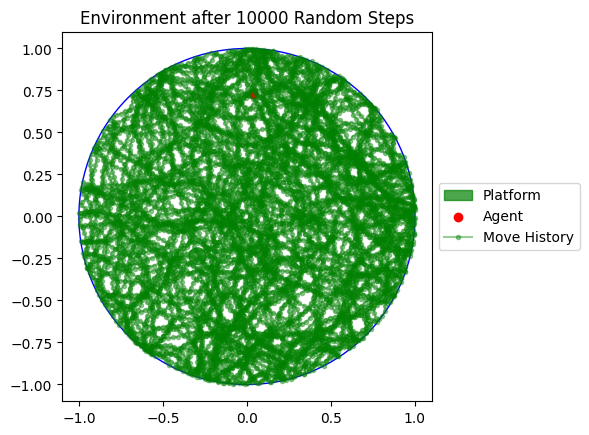

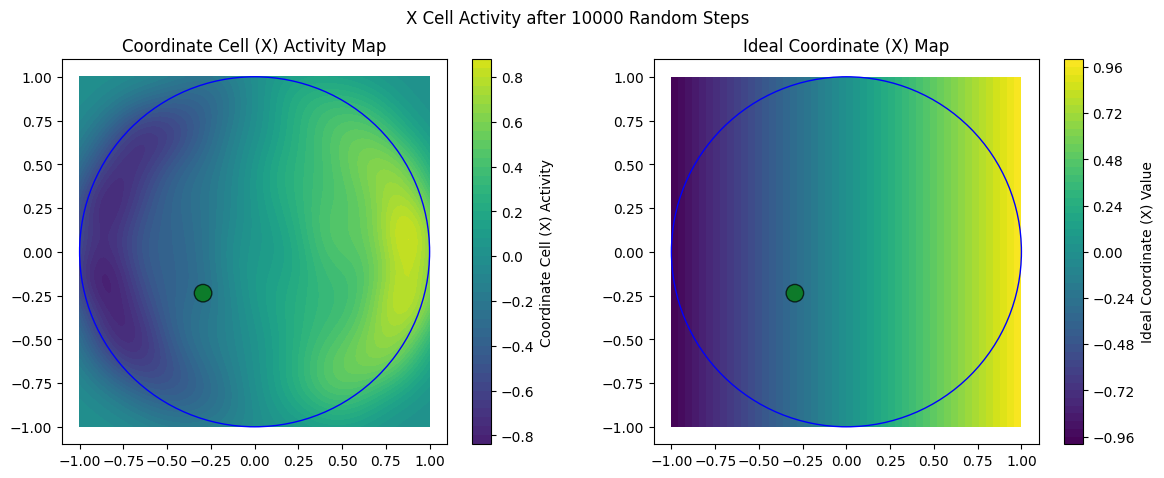

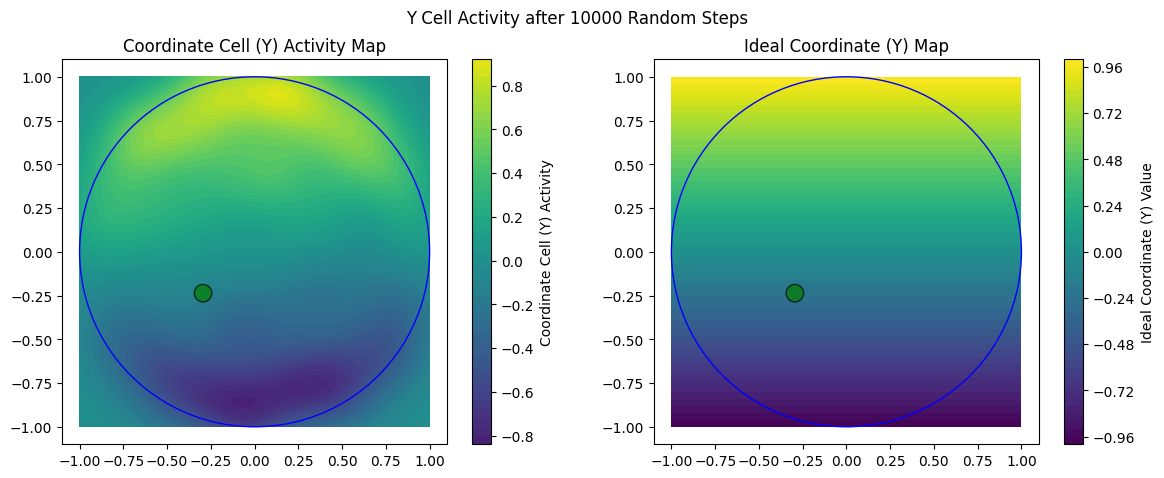

In [14]:
# Randomly move around for a while and see how well the coordinates are estimated
env = Environment(timeout=1000000)
c_agent = Coordinate_TD_Agent(env)
coords = Coordinates(c_agent)
n_steps = 10000
for step in range(n_steps):
    movement_vector = env.random_movement_vector()
    c_activation = c_agent.place_cells.get_activation(env.pos)
    temp_pos = env.pos.copy()
    env.step(movement_vector)
    real_movement_vector = env.pos - temp_pos
    n_activation = c_agent.place_cells.get_activation(env.pos)
    coords.update(c_activation, n_activation, real_movement_vector)
    # print 10 times during the whole n_steps
    if (step + 1) % (n_steps // 10) == 0:
        print(f"Step {step + 1}/{n_steps}")
# Display final results
env.display(title=f"Environment after {n_steps} Random Steps")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"X Cell Activity after {n_steps} Random Steps")
plt.sca(axes[0])
coords.display_cell_activity("x", plt_show=False)
plt.sca(axes[1])
coords.display_ideal_cell_activity("x", plt_show=False)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Y Cell Activity after {n_steps} Random Steps")
plt.sca(axes[0])
coords.display_cell_activity("y", plt_show=False)
plt.sca(axes[1])
coords.display_ideal_cell_activity("y", plt_show=False)
plt.show()

---
# Figure 6a
---

[(2, 2), (6, 2)]


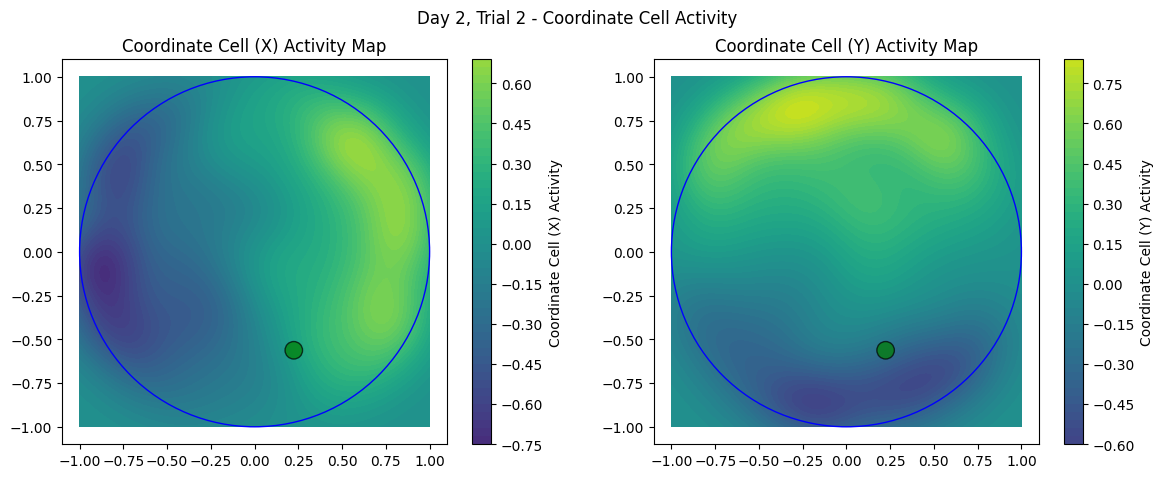

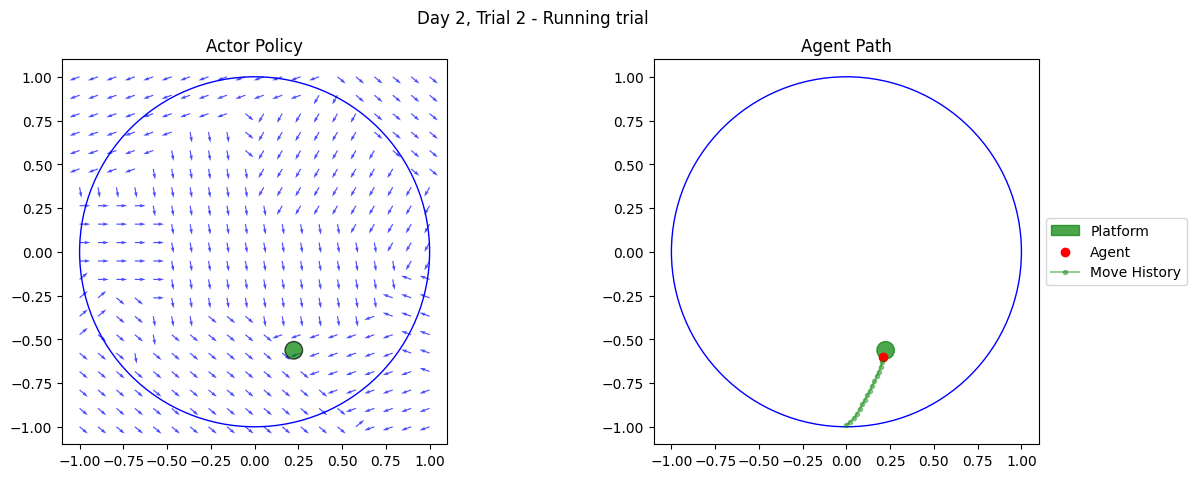

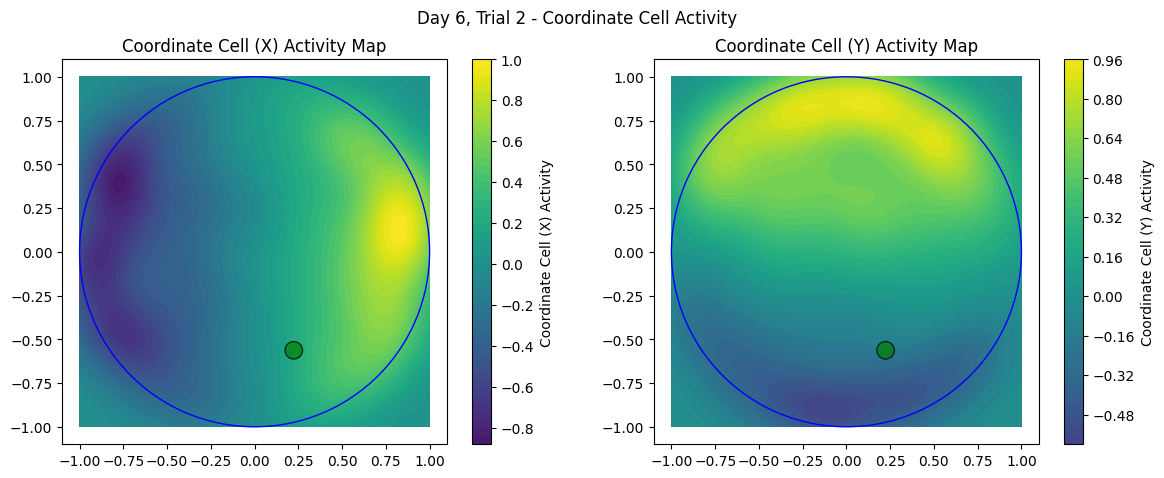

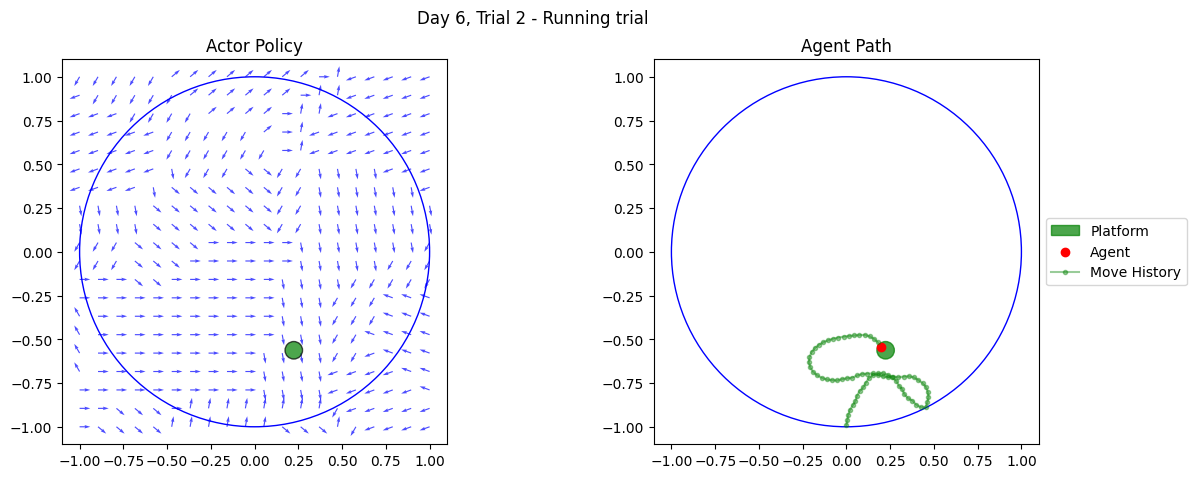

In [53]:
# Plot x and y cell activities at day 2, trial 2, and then day 6, trial 2
env = Environment()
c_agent = Coordinate_TD_Agent(env)
selected_trials = [(2, 2), (6, 2)]  # Day 2, trial 2 and Day 6, trial 2
selected_trial_ids = [(a-1)*4 + b for (a, b) in selected_trials]  # Convert to trial IDs
print(selected_trials)

for trial_num in range(max(selected_trial_ids) + 1):
    if trial_num in selected_trial_ids:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        day, trial = selected_trials[selected_trial_ids.index(trial_num)]
        fig.suptitle(f"Day {day}, Trial {trial} - Coordinate Cell Activity")
        plt.sca(axes[0])
        c_agent.coord_system.display_cell_activity("x", plt_show=False)
        plt.sca(axes[1])
        c_agent.coord_system.display_cell_activity("y", plt_show=False)
        plt.show()
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Day {day}, Trial {trial} - Running trial")
        plt.sca(axes[0])
        c_agent.actor.display_policy(plt_show=False, title=f"Actor Policy")
        _ = c_agent.run_trial("RMW")
        plt.sca(axes[1])
        env.display(plt_show=False, title="Agent Path")
        plt.show()
    else:
        _ = c_agent.run_trial("RMW")


---
# Coordinate TD Agent Class
---

Trial 1: 


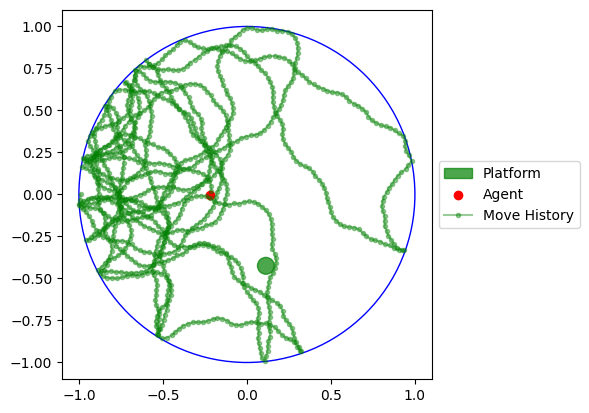

Trial 22: 


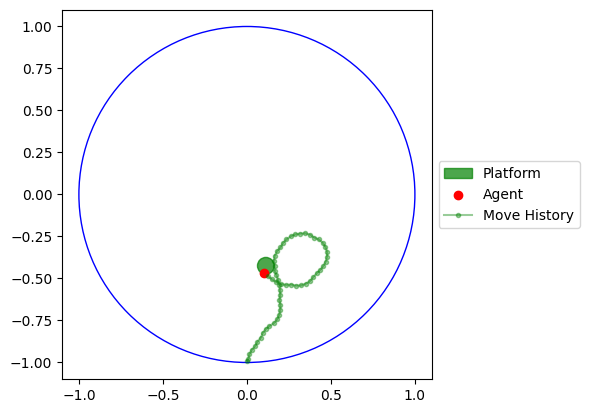

Trial 23 (DMP): 


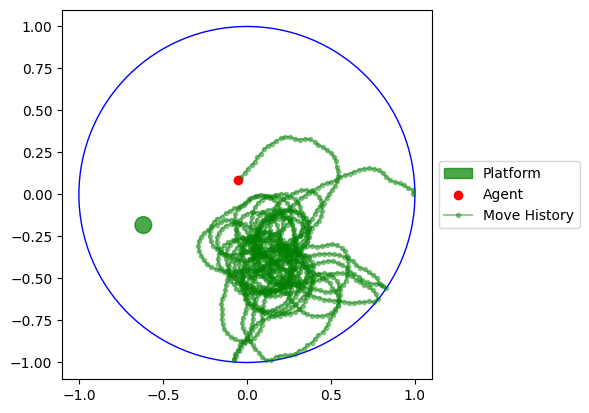

Trial 24 (RMW): 


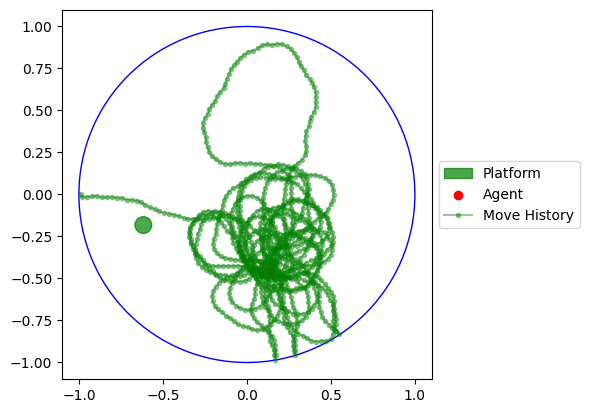

In [50]:
trial_count = 22
env = Environment()
agent = Coordinate_TD_Agent(env)
print(f"Trial 1: ")
#agent.critic.display_value_function()
agent.run_trial("RMW")
env.display()
for _ in range(trial_count - 2):
    agent.run_trial("RMW")
print(f"Trial {trial_count}: ")
#agent.critic.display_value_function()
agent.run_trial("RMW")
env.display()
print(f"Trial {trial_count + 1} (DMP): ")
agent.run_trial("DMP")
env.display()
print(f"Trial {trial_count + 2} (RMW): ")
agent.run_trial("RMW")
env.display()

---
# Figure 7
---

---
# Figure 8
---

## Figure 8a

Experiment Time: 9.36 seconds


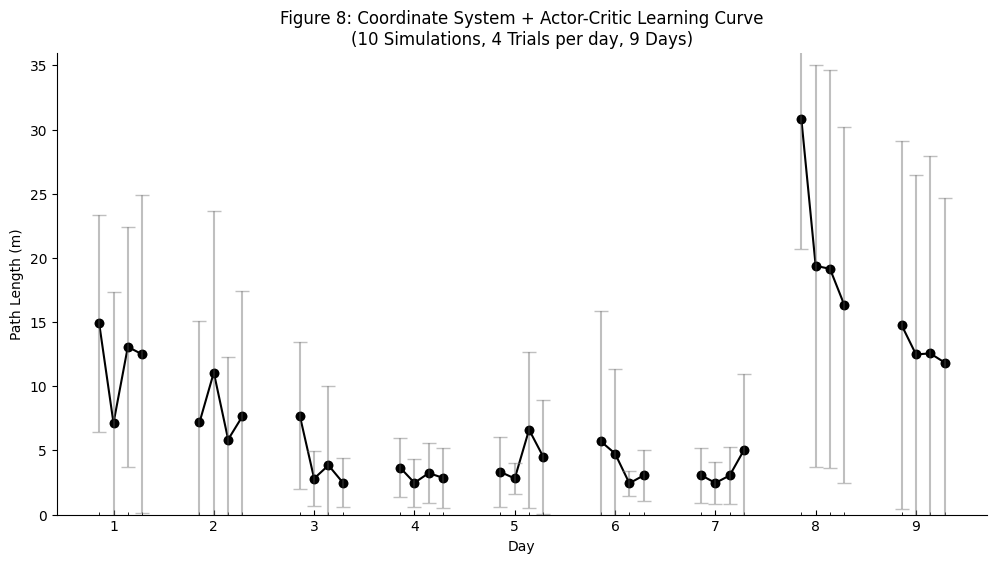

In [ ]:
env = Environment()
agent = Coordinate_TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 10

start_time = time.time()
results_8a = agent.run_figure8(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure8(results_8a, title=f"Figure 8a: RMW + DMP Task\n({simulation_count} Simulations, {trials_per_day} Trials per day, {len(trials_by_day)} Days)")

## Figure 8b

Experiment Time: 16.45 seconds


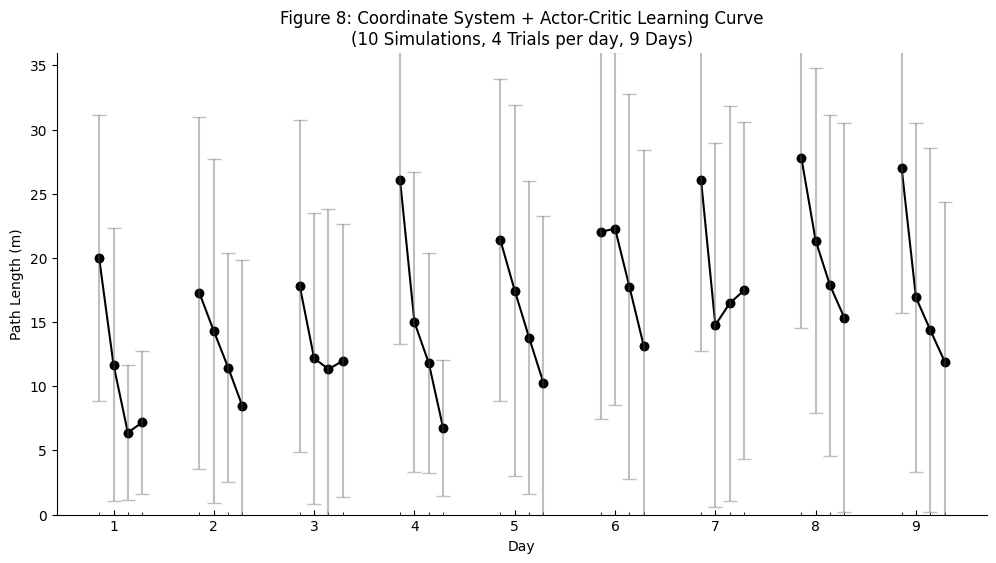

In [ ]:
env = Environment()
agent = Coordinate_TD_Agent(env)

trials_by_day = 9 * ["DMP"]
trials_per_day = 4
simulation_count = 10

start_time = time.time()
results_8b = agent.run_figure8(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
print(f"Experiment Time: {time.time() - start_time:.2f} seconds")
agent.display_figure8(results_8b, title=f"Figure 8b: DMP Task\n({simulation_count} Simulations, {trials_per_day} Trials per day, {len(trials_by_day)} Days)")